In [45]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
%matplotlib inline

In [46]:
df = pd.read_csv('index_price.csv')
df.head(2)

,company earnings,interest rate,inflation,market demand,index_price
0,29.43,27.36,10.66,79.85,321.01
1,54.35,25.02,2.52,33.81,257.26


In [47]:
df.drop(columns = ["company earnings","interest rate"], axis = 1,inplace = True)

In [48]:
df.head(3)

,inflation,market demand,index_price
0,10.66,79.85,321.01
1,2.52,33.81,257.26
2,7.20,38.05,223.43


In [49]:
df.isnull().sum()

inflation        0
market demand    0
index_price      0
dtype: int64

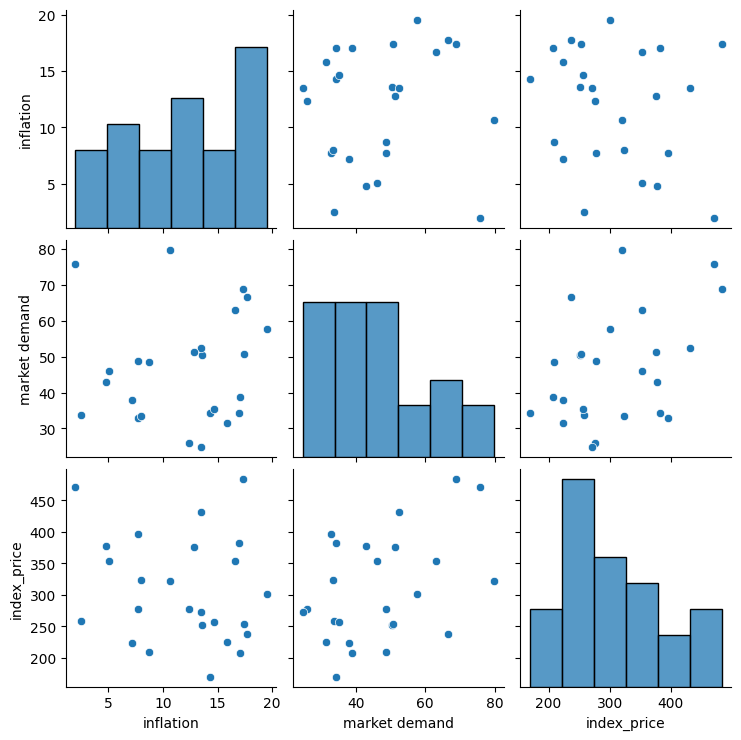

In [50]:
sns.pairplot(df)

In [51]:
df.corr()

,inflation,market demand,index_price
inflation,1.000000,0.065056,-0.190843
market demand,0.065056,1.000000,0.426553
index_price,-0.190843,0.426553,1.000000


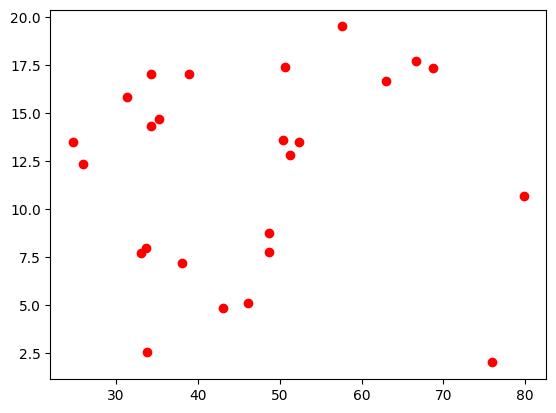

In [52]:
plt.scatter(df['market demand'],df['inflation'], color = 'red')

In [53]:
# X = df[['inflation','market demand']] it also mean 
X = df.iloc[:,:-1]
y = df.iloc[:,-1] # it also mean 
# y = df['index_price']

In [54]:
X.head()

,inflation,market demand
0,10.66,79.85
1,2.52,33.81
2,7.20,38.05
3,19.50,57.64
4,12.35,25.90


In [55]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = .25,random_state = 30)


<Axes: xlabel='inflation', ylabel='index_price'>

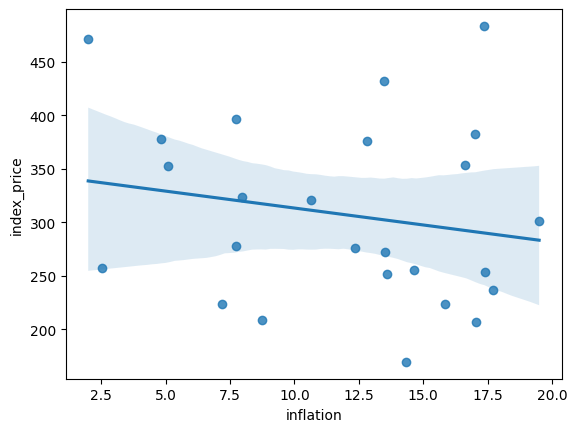

In [56]:
sns.regplot(x=df['inflation'], y=df['index_price'])

<Axes: xlabel='market demand', ylabel='index_price'>

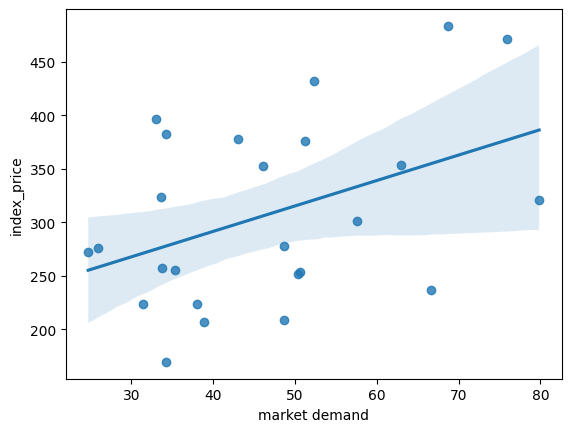

In [57]:
sns.regplot(x=df['market demand'], y=df['index_price'])

StandardScaler is used to put all features on the same scale so that machine learning models can learn properly and fairly.

After scaling:

    Mean = 0

    Standard deviation = 1

Standard deviation = average distance of data points from the mean

Small std → data points are close to the mean

Large std → data points are spread far from the mean

In [58]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [59]:
X_train

array([[ 0.39141979, -1.52460511],
       [-1.21235377,  0.12875818],
       [-0.7095079 , -0.88429417],
       [ 0.41046699,  0.45819352],
       [-1.69996188, -0.82242837],
       [-0.6599852 , -0.83866814],
       [ 1.06378567, -0.43190056],
       [-0.51522654,  0.32440875],
       [ 1.53425131,  1.02039891],
       [ 0.83712409, -1.01034572],
       [ 0.54760677, -0.7853089 ],
       [-0.8085533 , -0.49453968],
       [ 1.13235556,  0.47752658],
       [ 1.19330658,  1.71484242],
       [ 0.38951508,  0.61363133],
       [-0.70569846,  0.329822  ],
       [ 0.61236722, -0.70797666],
       [-1.800912  ,  2.43248561]])

In [60]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [61]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [62]:
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression,X_train,y_train,scoring = 'neg_mean_squared_error',
cv = 5)

In [63]:
np.mean(validation_score)

np.float64(-5929.6412064951655)

In [64]:
y_pred = regression.predict(X_test)

In [65]:
y_pred

array([273.71112392, 277.95731896, 336.35679354, 353.10908907,
       284.6045664 , 219.64091664, 243.52241369])

performance metric

In [66]:
from sklearn.metrics import mean_absolute_error , mean_squared_error

In [67]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)

print(mse)
print(mae)
print(rmse)

12465.829212908382
92.20942227397794
111.65047788929692


R sq and adjusted r2

In [68]:
from sklearn.metrics import r2_score

In [ ]:
score = r2_score(y_test,y_pred)
print(score)

-2.5568984117853204


In [70]:
#display adjusted R-squared
adj_r2 = 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print(adj_r2)

-4.33534761767798


Assumption

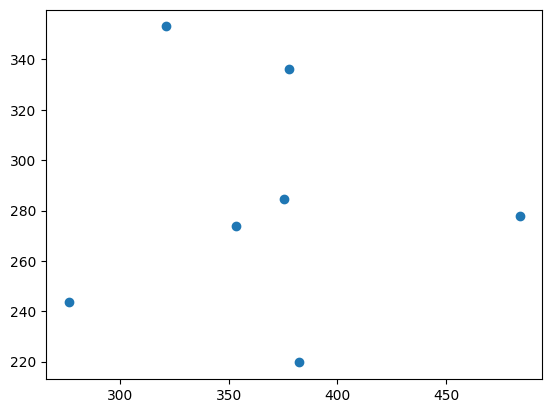

In [71]:
plt.scatter(y_test,y_pred)

In [72]:
residuals = y_test - y_pred
print(residuals)

10     79.578876
16    205.692681
19     41.293206
0     -32.099089
23     91.035434
6     162.819083
4      32.947586
Name: index_price, dtype: float64


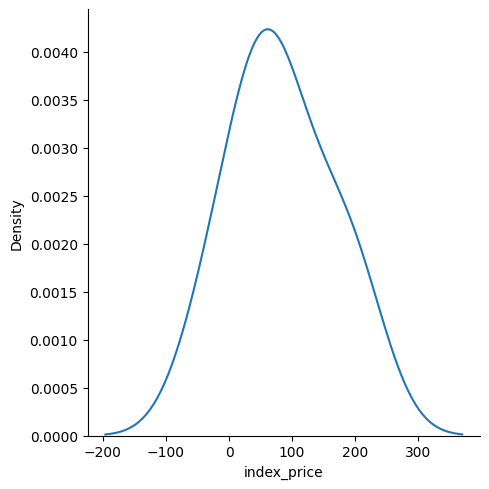

In [73]:
sns.displot(residuals, kind = 'kde')

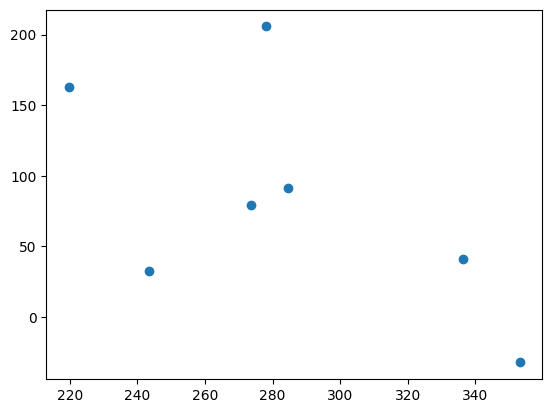

In [74]:
plt.scatter(y_pred, residuals)

In [75]:
%pip install statsmodels
import statsmodels.api as sm

Note: you may need to restart the kernel to use updated packages.


In [76]:
model = sm.OLS(y_train,X_train).fit()

In [77]:
prediction = model.predict(X_test)
print(prediction)

[-10.41776497  -6.17156993  52.22790465  68.98020018   0.47567751
 -64.48797225 -40.6064752 ]


In [79]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.025
Model:                            OLS   Adj. R-squared (uncentered):             -0.096
Method:                 Least Squares   F-statistic:                             0.2090
Date:                Sat, 17 Jan 2026   Prob (F-statistic):                       0.814
Time:                        15:03:20   Log-Likelihood:                         -127.68
No. Observations:                  18   AIC:                                      259.4
Df Residuals:                      16   BIC:                                      261.1
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [80]:
print(regression.coef_)

[-34.47772445  31.7895174 ]
